In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Lasso Regression
**Model:** Lasso Regression (L1 Regularization)  
**Dataset:** California Housing Dataset  
**Goal:** Predict median house value using Lasso regression with cross-validation hyperparameter tuning.

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('/content/drive/MyDrive/ECS 171 - Machine Learning/ProjectEDA/housing_cleaned.csv')
print(df.shape)
df.head()

(20640, 14)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,0.211155,0.567481,0.784314,0.022331,0.019863,0.008941,0.020556,0.539668,452600.0,False,False,False,True,False
1,0.212151,0.565356,0.392157,0.180503,0.171477,0.067210,0.186976,0.538027,358500.0,False,False,False,True,False
2,0.210159,0.564293,1.000000,0.037260,0.029330,0.013818,0.028943,0.466028,352100.0,False,False,False,True,False
3,0.209163,0.564293,1.000000,0.032352,0.036313,0.015555,0.035849,0.354699,341300.0,False,False,False,True,False
4,0.209163,0.564293,1.000000,0.041330,0.043296,0.015752,0.042427,0.230776,342200.0,False,False,False,True,False


## Train/Test Split
75% training, 25% testing (random_state=42 for reproducibility).

In [23]:
X = df.drop(columns=['median_house_value'])
y = df['median_house_value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (15480, 13)
Test size: (5160, 13)


## Hyperparameter Tuning (5-Fold Cross Validation)
Using 5-fold cross validation to find the optimal regularization parameter alpha (λ).
Higher alpha = stronger regularization = simpler model.

In [24]:
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = []
for alpha in alphas:
    model = Lasso(alpha=alpha, max_iter=10000)
    scores = cross_val_score(model, X_train, y_train,
                             cv=kf, scoring='neg_mean_squared_error')
    cv_scores.append(-scores.mean())
    print(f"Alpha={alpha}: CV MSE={-scores.mean():.2f}")

best_alpha = alphas[np.argmin(cv_scores)]
print(f"\nBest alpha: {best_alpha}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.837e+12, tolerance: 1.654e+10
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.758e+12, tolerance: 1.666e+10
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.669e+12, tolerance: 1.634e

Alpha=0.001: CV MSE=4736868228.80


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.837e+12, tolerance: 1.654e+10
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.758e+12, tolerance: 1.666e+10
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.669e+12, tolerance: 1.634e

Alpha=0.01: CV MSE=4736865499.48


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.839e+12, tolerance: 1.654e+10
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.760e+12, tolerance: 1.666e+10
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.671e+12, tolerance: 1.634e

Alpha=0.1: CV MSE=4736838468.85
Alpha=1: CV MSE=4736593771.68
Alpha=10: CV MSE=4736797278.50
Alpha=100: CV MSE=4857238572.99
Alpha=1000: CV MSE=5492057168.65

Best alpha: 1


## Final Model Training
Training Lasso with best alpha found from cross validation.
Evaluating with RMSE and R² on both train and test sets.

In [25]:
lasso = Lasso(alpha=best_alpha, max_iter=10000)
lasso.fit(X_train, y_train)

y_pred_train = lasso.predict(X_train)
y_pred_test = lasso.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

print(f"Train RMSE: {train_rmse:.2f}")
print(f"Test RMSE:  {test_rmse:.2f}")
print(f"Train R²:   {train_r2:.4f}")
print(f"Test R²:    {test_r2:.4f}")

Train RMSE: 68610.82
Test RMSE:  69257.34
Train R²:   0.6472
Test R²:    0.6375


## Feature Analysis
Key property of Lasso (L1): can shrink coefficients to exactly zero, performing automatic feature selection.

Features zeroed out by Lasso: 1
                       Feature   Coefficient
5                   population -1.347719e+06
4               total_bedrooms  6.834309e+05
7                median_income  5.693227e+05
0                    longitude -2.701994e+05
6                   households  2.615342e+05
1                     latitude -2.389219e+05
3                  total_rooms -2.313477e+05
10      ocean_proximity_ISLAND  1.318268e+05
2           housing_median_age  5.583795e+04
9       ocean_proximity_INLAND -4.010073e+04
11    ocean_proximity_NEAR BAY -5.913255e+03
12  ocean_proximity_NEAR OCEAN  3.706679e+03
8    ocean_proximity_<1H OCEAN  0.000000e+00


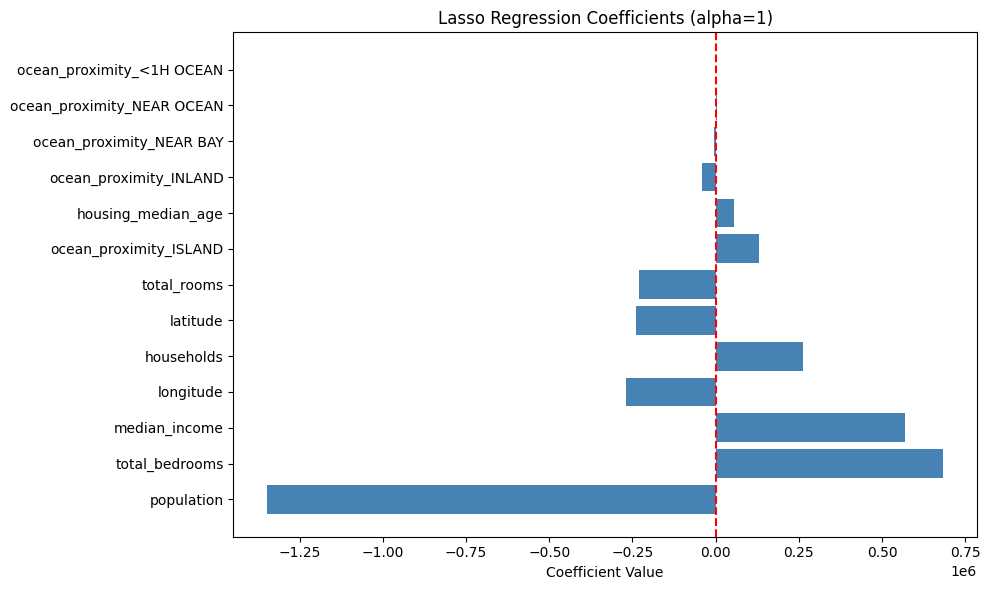

In [26]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lasso.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("Features zeroed out by Lasso:", (coef_df['Coefficient'] == 0).sum())
print(coef_df)

plt.figure(figsize=(10, 6))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title(f'Lasso Regression Coefficients (alpha={best_alpha})')
plt.axvline(x=0, color='red', linestyle='--')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ECS 171 - Machine Learning/ProjectEDA/lasso_coefficients.png', dpi=150)
plt.show()

## Residual Analysis
Residuals = actual - predicted. A good model has residuals randomly scattered around zero.

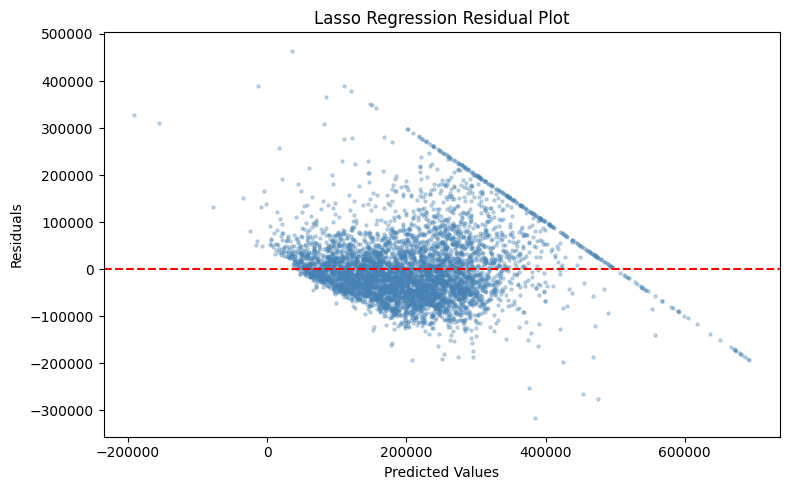

In [27]:
residuals = y_test - y_pred_test

plt.figure(figsize=(8, 5))
plt.scatter(y_pred_test, residuals, alpha=0.3, s=5, color='steelblue')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Lasso Regression Residual Plot')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/ECS 171 - Machine Learning/ProjectEDA/lasso_residuals.png', dpi=150)
plt.show()